# 04 — First training loop

We will train ResNet18 to recognise the three cat breeds. On this CPU laptop, we first train **only the new final layer** for one epoch (one complete pass through the training images). The official test split is deliberately not used here.

Training loop: `images → model logits → loss → backpropagation → optimizer updates weights`. Validation is a separate, no-learning measurement after the epoch.

In [ ]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0  # safest setting for Windows and this CPU laptop
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SELECTED_CLASSES = ['Abyssinian', 'Bengal', 'Egyptian Mau']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
print('CPU training is expected on this laptop.')

In [ ]:
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / 'pyproject.toml').exists() else CURRENT_FOLDER.parent
METADATA_PATH = PROJECT_ROOT / 'data' / 'classification_crops' / 'metadata.csv'

assert METADATA_PATH.exists(), f'Missing crop metadata: {METADATA_PATH}'
records = pd.read_csv(METADATA_PATH)
assert set(records['class_name']) == set(SELECTED_CLASSES)
assert set(records['split']) == {'train', 'val', 'test'}

display(records.groupby(['split', 'class_name']).size().unstack(fill_value=0))
print(f'Loaded {len(records)} crop records. Test rows will not be put in a DataLoader today.')

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PetCropDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image_path = PROJECT_ROOT / row['crop_path']
        with Image.open(image_path) as image:
            image = image.convert('RGB')
        return self.transform(image), int(row['label_id'])

train_records = records.query("split == 'train'")
val_records = records.query("split == 'val'")
train_loader = DataLoader(PetCropDataset(train_records, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(PetCropDataset(val_records, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Training batches:   {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

## Transfer learning setup

ResNet18 arrives with useful image features learned from ImageNet. We freeze its old feature-extracting weights and replace its last layer with three new outputs. Therefore, in this first experiment, backpropagation updates only the new layer.

In [ ]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for parameter in model.parameters():
    parameter.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(SELECTED_CLASSES))
model = model.to(DEVICE)

trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
all_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'Trainable parameters: {trainable_parameters:,} of {all_parameters:,}')
print('Only model.fc is trainable:', all(parameter.requires_grad for parameter in model.fc.parameters()))

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
print('Loss: CrossEntropyLoss (it expects raw logits, not softmax probabilities)')
print('Optimizer: AdamW (changes the trainable weights after backpropagation)')

In [ ]:
def train_one_epoch(model, loader, loss_function, optimizer):
    model.train()  # training mode: learning is allowed
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_function):
    model.eval()  # evaluation mode: no learning happens here
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = loss_function(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

print('The two functions are ready. In the training function, backward() calculates gradients and step() updates weights.')

## Run one epoch

An **epoch** means the model sees all 232 training crops once. Run this cell once first. It may take a few minutes on the CPU; do not press Stop while it is running. We will interpret its validation result together before choosing whether to run more epochs.

In [ ]:
history = []
start_time = time.perf_counter()

train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_function, optimizer)
val_loss, val_accuracy = evaluate(model, val_loader, loss_function)
elapsed_seconds = time.perf_counter() - start_time

history.append({
    'epoch': 1,
    'train_loss': train_loss,
    'train_accuracy': train_accuracy,
    'val_loss': val_loss,
    'val_accuracy': val_accuracy,
})
history_frame = pd.DataFrame(history)
display(history_frame.round(3))
print(f'One CPU epoch took {elapsed_seconds:.1f} seconds.')
print(f'Validation accuracy: {val_accuracy:.1%} (compare only with the 34.5% majority-class baseline for now)')
print('The official test set is still untouched.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_frame['epoch'], history_frame['train_loss'], marker='o', label='train')
axes[0].plot(history_frame['epoch'], history_frame['val_loss'], marker='o', label='validation')
axes[0].set(title='Loss', xlabel='epoch', ylabel='cross-entropy loss')
axes[0].legend()
axes[1].plot(history_frame['epoch'], history_frame['train_accuracy'], marker='o', label='train')
axes[1].plot(history_frame['epoch'], history_frame['val_accuracy'], marker='o', label='validation')
axes[1].axhline(0.345, color='gray', linestyle='--', label='majority baseline')
axes[1].set(title='Accuracy', xlabel='epoch', ylabel='accuracy', ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

print('With one point per line, the chart is only a record. It becomes useful after later epochs.')

## Continue to five epochs

The first epoch was fast enough to continue. This cell adds epochs 2–5 to the same model: it does **not** restart the model or repeat epoch 1. We still make choices only from validation results.

In [8]:
TOTAL_EPOCHS = 5
start_time = time.perf_counter()

for epoch in range(2, TOTAL_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_function, optimizer)
    val_loss, val_accuracy = evaluate(model, val_loader, loss_function)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
    })
    print(f'Epoch {epoch}: train accuracy={train_accuracy:.1%}, validation accuracy={val_accuracy:.1%}')

history_frame = pd.DataFrame(history)
display(history_frame.round(3))
print(f'Four additional CPU epochs took {time.perf_counter() - start_time:.1f} seconds.')
print('The test split remains untouched.')

Epoch 2: train accuracy=67.7%, validation accuracy=65.5%
Epoch 3: train accuracy=82.3%, validation accuracy=79.3%
Epoch 4: train accuracy=82.3%, validation accuracy=60.3%
Epoch 5: train accuracy=80.2%, validation accuracy=81.0%


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.078,0.440,0.942,0.552
1,2,0.811,0.677,0.805,0.655
2,3,0.633,0.823,0.720,0.793
3,4,0.558,0.823,0.730,0.603
4,5,0.535,0.802,0.624,0.810


Four additional CPU epochs took 47.8 seconds.
The test split remains untouched.


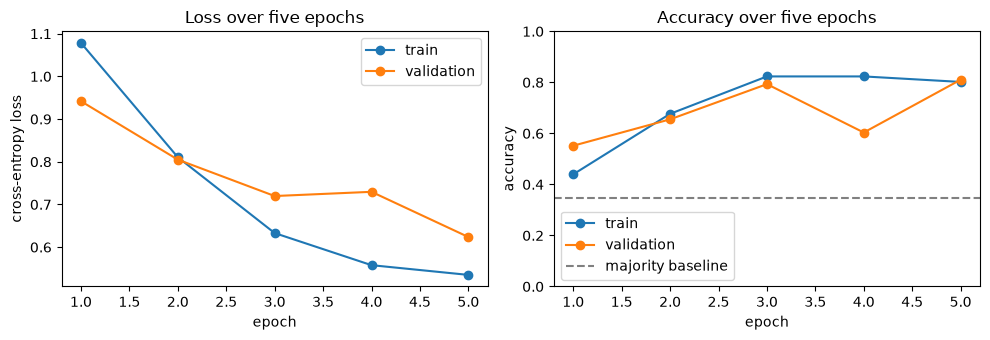

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_frame['epoch'], history_frame['train_loss'], marker='o', label='train')
axes[0].plot(history_frame['epoch'], history_frame['val_loss'], marker='o', label='validation')
axes[0].set(title='Loss over five epochs', xlabel='epoch', ylabel='cross-entropy loss')
axes[0].legend()
axes[1].plot(history_frame['epoch'], history_frame['train_accuracy'], marker='o', label='train')
axes[1].plot(history_frame['epoch'], history_frame['val_accuracy'], marker='o', label='validation')
axes[1].axhline(0.345, color='gray', linestyle='--', label='majority baseline')
axes[1].set(title='Accuracy over five epochs', xlabel='epoch', ylabel='accuracy', ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

### Stop and inspect

Send the five-row table and chart before we make another model choice. Do not evaluate the test split yet.

## Save this trained checkpoint

A notebook save preserves code and displayed output, but trained weight values live in the kernel's memory. This cell writes those values and the training history to a local checkpoint so a later notebook can load the exact epoch-5 model. The checkpoint is intentionally not committed to Git because model files can be large.

In [10]:
CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_epoch5.pt'
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': SELECTED_CLASSES,
    'image_size': 224,
    'history': history,
    'training_setup': 'ResNet18 pretrained; feature extractor frozen; final layer trained for 5 epochs',
}, CHECKPOINT_PATH)

assert CHECKPOINT_PATH.exists()
print(f'Checkpoint saved: {CHECKPOINT_PATH}')
print(f'File size: {CHECKPOINT_PATH.stat().st_size / 1024 / 1024:.1f} MB')

Checkpoint saved: D:\Projects\parrot-detector\models\part2_resnet18_frozen_head_epoch5.pt
File size: 42.7 MB
